
# 20_forward_model_simple.ipynb — Phase 1 (Pendulum-v1)
**Model-Based RL (toy): Forward Model + Random Shooting (MPC) + PPO Baseline**

Bu defter:
- **Pendulum-v1** üzerinde ileri dinamik modeli (MLP, delta-obs) öğrenir,
- **Random Shooting MPC** ile kapalı çevrim kontrol yapar,
- **PPO kısa baseline** ile karşılaştırır.
- **Klasörleme & TensorBoard**: `runs/Phase 1/20_forward_model_simple/<RUN_ID>/...` standardını kullanır.


## 1) Kurulum (gerekiyorsa çalıştırın)

In [1]:

# %pip install -U gymnasium stable-baselines3 tensorboard pandas matplotlib tqdm


## 2) Kütüphaneler & Bootstrap

In [2]:

import sys, os, time, uuid, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# Bootstrap yardımcılarını bu oturumda oluşturuyoruz (aynı hücrede dursun, dış bağımlılık olmasın)
from tensorboard.backend.event_processing import event_accumulator as ea
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import set_random_seed

class RLBootstrap:
    def __init__(self, phase, notebook, step, env_id, seed=42):
        self.phase, self.notebook, self.step, self.env_id = phase, notebook, step, env_id
        self.seed = seed
        set_random_seed(seed); np.random.seed(seed); random.seed(seed)
        self.run_id   = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
        self.root_dir = os.path.join("runs", self.phase, self.notebook, self.run_id)
        self.ckpt_dir = os.path.join(self.root_dir, "checkpoints")
        self.mon_dir  = os.path.join(self.root_dir, "monitor")
        os.makedirs(self.ckpt_dir, exist_ok=True); os.makedirs(self.mon_dir, exist_ok=True)
        self._write_meta()

    def algo_dir(self, algo_name: str) -> str:
        safe_env = self.env_id.replace("-", "_")
        d = os.path.join(self.root_dir, f"{algo_name}_{safe_env}")
        os.makedirs(d, exist_ok=True)
        return d

    def make_env(self, render=False, monitor=True):
        env = gym.make(self.env_id, render_mode="human") if render else gym.make(self.env_id)
        if monitor:
            md = os.path.join(self.mon_dir, self.env_id.replace("-", "_"))
            os.makedirs(md, exist_ok=True)
            env = Monitor(env, md)
        return env

    def make_logger(self, algo_name: str):
        d = self.algo_dir(algo_name)
        return configure(d, ["stdout","csv","tensorboard"]), d

    def _write_meta(self):
        m = {"phase": self.phase, "notebook": self.notebook, "step": self.step,
             "env": self.env_id, "seed": self.seed, "run_id": self.run_id,
             "root_dir": self.root_dir, "ckpt_dir": self.ckpt_dir, "monitor_dir": self.mon_dir}
        os.makedirs(self.root_dir, exist_ok=True)
        with open(os.path.join(self.root_dir, "meta.json"), "w") as f: json.dump(m, f, indent=2)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


Device: mps


## 3) Deney Ayarları ve Klasör Yapısı

In [3]:

PHASE    = "Phase 2"
NOTEBOOK = "20_forward_model_simple"
STEP     = "ForwardModel+RandomShooting"
ENV_ID   = "Pendulum-v1"
SEED     = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

boot = RLBootstrap(phase=PHASE, notebook=NOTEBOOK, step=STEP, env_id=ENV_ID, seed=SEED)

FM_LOG   = boot.algo_dir("ForwardModel")
MPC_LOG  = boot.algo_dir("MPC_RS")
BASE_LOG = boot.algo_dir("Baseline_PPO")
CKPT_FM_DIR   = os.path.join(boot.ckpt_dir, "ForwardModel_Pendulum_v1")
CKPT_MPC_DIR  = os.path.join(boot.ckpt_dir, "MPC_RS_Pendulum_v1")
CKPT_BASE_DIR = os.path.join(boot.ckpt_dir, "Baseline_Pendulum_v1")
os.makedirs(CKPT_FM_DIR, exist_ok=True); os.makedirs(CKPT_MPC_DIR, exist_ok=True); os.makedirs(CKPT_BASE_DIR, exist_ok=True)

print("ROOT_DIR:", boot.root_dir)
print("FM_LOG  :", FM_LOG)
print("MPC_LOG :", MPC_LOG)
print("BASE_LOG:", BASE_LOG)


ROOT_DIR: runs/Phase 2/20_forward_model_simple/20251008-130750-120495
FM_LOG  : runs/Phase 2/20_forward_model_simple/20251008-130750-120495/ForwardModel_Pendulum_v1
MPC_LOG : runs/Phase 2/20_forward_model_simple/20251008-130750-120495/MPC_RS_Pendulum_v1
BASE_LOG: runs/Phase 2/20_forward_model_simple/20251008-130750-120495/Baseline_PPO_Pendulum_v1


## 4) Kaynak Dosyalar — dynamics ve planner (oturumda yazılır)

In [4]:

# dynamics model
class MLPDynamics(nn.Module):
    """(s,a)->Δs tahmin eden MLP; step() ile s_next üretir ve [cos,sin] normalizasyonu yapar."""
    def __init__(self, obs_dim, act_dim, hidden=256, predict_delta=True):
        super().__init__()
        self.predict_delta = predict_delta
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim)
        )
    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        out = self.net(x)
        return out
    def step(self, s, a):
        with torch.no_grad():
            delta = self.forward(s, a)
            s_next = s + delta
        s_next = s_next.clone()
        r = torch.norm(s_next[..., :2], dim=-1, keepdim=True) + 1e-8
        s_next[..., :2] = s_next[..., :2] / r
        return s_next

def pendulum_reward(obs, act):
    cos_t, sin_t, dtheta = obs[...,0], obs[...,1], obs[...,2]
    theta = torch.atan2(sin_t, cos_t)
    cost = theta*theta + 0.1*(dtheta**2) + 0.001*(act.squeeze(-1)**2)
    return -cost

class RandomShootingMPC:
    def __init__(self, model, act_low, act_high, horizon=25, n_samples=1024, device="cpu", sample_type='uniform'):
        """Planner with configurable sampling: 'uniform' (original) or 'gaussian'."""
        self.model, self.act_low, self.act_high = model, float(act_low), float(act_high)
        self.horizon, self.n_samples, self.device = horizon, n_samples, device
        assert sample_type in ('uniform','gaussian'), 'sample_type must be uniform or gaussian'
        self.sample_type = sample_type

    def act(self, s_now):
        # ensure tensor state on device, shape [state_dim] or [1,state_dim]
        if not torch.is_tensor(s_now):
            s0 = torch.as_tensor(s_now, dtype=torch.float32, device=self.device).unsqueeze(0)
        else:
            s0 = s_now.to(self.device).unsqueeze(0) if s_now.ndim==1 else s_now.to(self.device)

        if self.sample_type == 'gaussian':
            # gaussian sampling centered at 0, scale tuned to action range
            scale = (self.act_high - self.act_low) / 2.0
            acts = (torch.randn(self.n_samples, self.horizon, 1, device=self.device) * scale).clamp(self.act_low, self.act_high)
        else:
            acts = (torch.rand(self.n_samples, self.horizon, 1, device=self.device) * (self.act_high - self.act_low) + self.act_low)

        s = s0.repeat(self.n_samples, 1); total = torch.zeros(self.n_samples, device=self.device)
        with torch.no_grad():
            for t in range(self.horizon):
                a_t = acts[:, t, :]
                total += pendulum_reward(s, a_t)
                s = self.model.step(s, a_t)
        best = torch.argmax(total).item()
        a0 = acts[best, 0, :].clamp(self.act_low, self.act_high)
        return a0.detach().cpu().numpy()


## 5) Veri Toplama (Random rollouts)

In [5]:

def collect_random(env, steps=60000):
    obs_list, act_list, next_list = [], [], []
    obs, info = env.reset(seed=SEED)
    for _ in tqdm(range(steps), desc="Collect"):
        a = env.action_space.sample()
        nobs, r, done, trunc, info = env.step(a)
        obs_list.append(obs); act_list.append(a); next_list.append(nobs)
        obs = nobs
        if done or trunc:
            obs, info = env.reset()
    return np.array(obs_list, np.float32), np.array(act_list, np.float32), np.array(next_list, np.float32)

env = boot.make_env(monitor=True)
OBS, ACT, NEXT = collect_random(env, steps=60000)
env.close()
print("Dataset:", OBS.shape, ACT.shape, NEXT.shape)


Collect:   0%|          | 0/60000 [00:00<?, ?it/s]

Dataset: (60000, 3) (60000, 1) (60000, 3)


## 6) Dataset / DataLoader

In [6]:

class FMDataset(Dataset):
    def __init__(self, obs, act, next_obs, predict_delta=True):
        self.obs, self.act, self.next = obs, act, next_obs
        self.predict_delta = predict_delta
    def __len__(self): return len(self.obs)
    def __getitem__(self, i):
        s = self.obs[i]; a = self.act[i]; ns = self.next[i]
        y = ns - s if self.predict_delta else ns
        return s, a, y, ns

N = len(OBS); idx = np.arange(N); np.random.shuffle(idx)
train_idx = idx[: int(0.9*N)]; val_idx = idx[int(0.9*N):]

train_ds = FMDataset(OBS[train_idx], ACT[train_idx], NEXT[train_idx], predict_delta=True)
val_ds   = FMDataset(OBS[val_idx],   ACT[val_idx],   NEXT[val_idx],   predict_delta=True)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, drop_last=False)
print("Train/Val:", len(train_ds), len(val_ds))


Train/Val: 54000 6000


## 7) Forward Model Eğitimi (1-step & k-step MSE, TB log)

In [7]:
from torch.utils.tensorboard import SummaryWriter

obs_dim, act_dim = OBS.shape[1], ACT.shape[1]
fm = MLPDynamics(obs_dim, act_dim, hidden=256, predict_delta=True).to(device)
opt = optim.Adam(fm.parameters(), lr=3e-4)

writer = SummaryWriter(FM_LOG)
best_val = float("inf")
ckpt_path = os.path.join(CKPT_FM_DIR, "forward_model.pt")
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

def collect_sequential(env, n_episodes=10, max_steps=200):
    """Collect short sequential trajectories (obs, act, next) for multi-step validation."""
    trajs = []
    for ep in range(n_episodes):
        traj = {'obs': [], 'act': [], 'next': []}
        obs, info = env.reset(seed=SEED+ep)
        for t in range(max_steps):
            a = env.action_space.sample()
            nobs, r, done, trunc, info = env.step(a)
            traj['obs'].append(np.array(obs, dtype=np.float32))
            traj['act'].append(np.array(a, dtype=np.float32))
            traj['next'].append(np.array(nobs, dtype=np.float32))
            obs = nobs
            if done or trunc: break
        tr = {k: np.asarray(v) for k,v in traj.items()}
        tr['length'] = len(tr['obs'])
        trajs.append(tr)
    return trajs

def multi_step_mse(model, trajectories, k=5):
    """Compute avg MSE of k-step predictions using real action sequences from trajectories."""
    model.eval(); errors = []
    with torch.no_grad():
        for traj in trajectories:
            L = traj['length']
            if L <= k:
                continue
            obs_arr = traj['obs']; act_arr = traj['act']; next_arr = traj['next']
            for start in range(0, L - k):
                s = torch.as_tensor(obs_arr[start], dtype=torch.float32, device=device).unsqueeze(0)
                true_seq = next_arr[start:start+k]  # shape (k, obs_dim)
                preds = []
                for t in range(k):
                    a_t = torch.as_tensor(act_arr[start + t], dtype=torch.float32, device=device).unsqueeze(0)
                    s = model.step(s, a_t)
                    preds.append(s.squeeze(0).cpu().numpy())
                preds = np.stack(preds, axis=0)
                mse = float(((preds - true_seq)**2).mean())
                errors.append(mse)
    return float(np.mean(errors)) if errors else 0.0

EPOCHS=40; gs=0
patience = 5
best_val = float('inf')
no_improve = 0

# collect sequential validation trajectories once (small number)
val_env = boot.make_env(monitor=False)
seq_trajs = collect_sequential(val_env, n_episodes=10, max_steps=200)
val_env.close()

for ep in range(1, EPOCHS+1):
    fm.train(); tr_loss = 0.0
    for s,a,y,_ in train_loader:
        s=s.to(device); a=a.to(device); y=y.to(device)
        pred = fm(s,a); loss = nn.MSELoss()(pred,y)
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(fm.parameters(), 5.0); opt.step()
        writer.add_scalar("train/1step_mse", loss.item(), gs); gs+=1; tr_loss+=loss.item()
    # validation 1-step
    fm.eval(); val=0.0; n=0
    with torch.no_grad():
        for s,a,y,_ in val_loader:
            s=s.to(device); a=a.to(device); y=y.to(device)
            l=nn.MSELoss()(fm(s,a), y); val+=l.item(); n+=1
    val /= max(1,n)
    # multi-step on sequential trajectories
    k5  = multi_step_mse(fm, seq_trajs, k=5)
    k10 = multi_step_mse(fm, seq_trajs, k=10)
    writer.add_scalar("val/1step_mse", val, ep)
    writer.add_scalar("val/kstep_mse_k5",  k5,  ep)
    writer.add_scalar("val/kstep_mse_k10", k10, ep)
    print(f"[EP {ep:03d}] train={tr_loss/len(train_loader):.6f} val={val:.6f} k5={k5:.6f} k10={k10:.6f}")
    if val < best_val - 1e-9:
        best_val = val; torch.save(fm.state_dict(), ckpt_path); no_improve = 0
    else:
        no_improve += 1
    if no_improve >= patience:
        print(f"Early stopping at ep={ep} (no_improve={no_improve})")
        break

writer.flush(); writer.close()
print("Saved best FM to:", ckpt_path, "| best val(1step)=", best_val)


[EP 001] train=0.006859 val=0.000297 k5=0.001594 k10=0.005728
[EP 002] train=0.000222 val=0.000201 k5=0.000849 k10=0.002298
[EP 002] train=0.000222 val=0.000201 k5=0.000849 k10=0.002298
[EP 003] train=0.000174 val=0.000248 k5=0.001277 k10=0.003317
[EP 003] train=0.000174 val=0.000248 k5=0.001277 k10=0.003317
[EP 004] train=0.000173 val=0.000172 k5=0.001081 k10=0.003585
[EP 004] train=0.000173 val=0.000172 k5=0.001081 k10=0.003585
[EP 005] train=0.000159 val=0.000178 k5=0.000906 k10=0.002165
[EP 005] train=0.000159 val=0.000178 k5=0.000906 k10=0.002165
[EP 006] train=0.000172 val=0.000147 k5=0.000610 k10=0.001390
[EP 006] train=0.000172 val=0.000147 k5=0.000610 k10=0.001390
[EP 007] train=0.000152 val=0.000192 k5=0.001258 k10=0.004284
[EP 007] train=0.000152 val=0.000192 k5=0.001258 k10=0.004284
[EP 008] train=0.000144 val=0.000154 k5=0.000680 k10=0.001623
[EP 008] train=0.000144 val=0.000154 k5=0.000680 k10=0.001623
[EP 009] train=0.000146 val=0.000183 k5=0.001101 k10=0.002868
[EP 009]

## 8) MPC (Random Shooting) — Kapalı Çevrim

In [8]:

fm2 = MLPDynamics(obs_dim, act_dim, hidden=256, predict_delta=True).to(device)
fm2.load_state_dict(torch.load(ckpt_path, map_location=device))

tmp = gym.make(ENV_ID)
low, high = float(tmp.action_space.low[0]), float(tmp.action_space.high[0])
tmp.close()

planner = RandomShootingMPC(fm2, low, high, horizon=25, n_samples=1024, device=device)

def run_mpc(n_episodes=10, max_steps=200):
    env = boot.make_env(monitor=False); rets=[]
    for ep in range(n_episodes):
        obs, info = env.reset(seed=SEED+ep); ret=0.0
        for t in range(max_steps):
            a = planner.act(obs)
            obs, r, done, trunc, info = env.step(a)
            ret += r
            if done or trunc: break
        rets.append(ret)
    env.close(); return float(np.mean(rets)), float(np.std(rets))

mpc_mean, mpc_std = run_mpc(10, 200)
print(f"[MPC] mean={mpc_mean:.1f} ± {mpc_std:.1f}")

from torch.utils.tensorboard import SummaryWriter
w = SummaryWriter(MPC_LOG)
w.add_scalar("eval/return_mean", mpc_mean, 0)
w.add_scalar("eval/return_std",  mpc_std,  0)
w.flush(); w.close()


[MPC] mean=-233.8 ± 153.0


## 9) Model‑Free Baseline (PPO — kısa)

In [9]:

train_env = boot.make_env(monitor=True); eval_env = gym.make(ENV_ID)
eval_cb = EvalCallback(eval_env,
                       best_model_save_path=CKPT_BASE_DIR,
                       log_path=BASE_LOG,
                       eval_freq=5_000,
                       n_eval_episodes=5,
                       deterministic=True,
                       verbose=0)  # reduced verbosity

ckpt_cb = CheckpointCallback(save_freq=20_000,
                             save_path=CKPT_BASE_DIR,
                             name_prefix="ckpt",
                             verbose=0)  # reduced verbosity

ppo = PPO("MlpPolicy", train_env, device="auto", seed=SEED, verbose=0)  # silence SB3 logs
# remove stdout from logger to avoid extra console output
ppo.set_logger(configure(BASE_LOG, ["csv","tensorboard"]))
# reduce progress output
ppo.learn(total_timesteps=120_000, callback=[eval_cb, ckpt_cb], progress_bar=False)
ppo.save(os.path.join(CKPT_BASE_DIR, "final_ppo.zip"))
mean_r, std_r = evaluate_policy(ppo, eval_env, n_eval_episodes=10, deterministic=True)
print(f"[PPO] mean={mean_r:.1f} ± {std_r:.1f}")
train_env.close(); eval_env.close()

wb = SummaryWriter(BASE_LOG)
wb.add_scalar("eval/return_mean", mean_r, 0); wb.add_scalar("eval/return_std", std_r, 0)
wb.flush(); wb.close()


[PPO] mean=-975.4 ± 148.4


## 10) Karşılaştırma Grafikleri (TB event’lerinden)

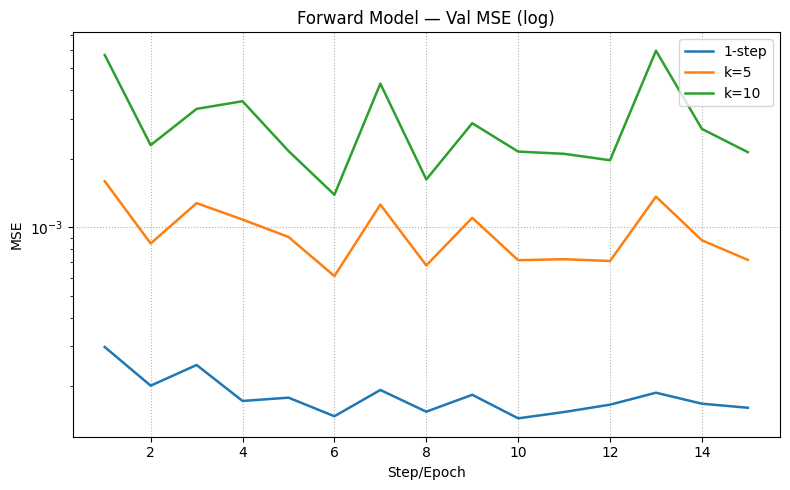

In [10]:

def tb_series(run_dir: str, tag: str):
    files = []
    for root, _, fs in os.walk(run_dir):
        for f in fs:
            if f.startswith("events.out.tfevents"):
                files.append(os.path.join(root, f))
    if not files: return None
    import pandas as pd
    dfs=[]
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={"scalars": 10**7})
            acc.Reload()
            if tag in acc.Tags().get("scalars", []):
                s = acc.Scalars(tag)
                dfs.append(pd.DataFrame({"step":[i.step for i in s], "val":[i.value for i in s]}))
        except Exception as ex:
            print("[WARN] TB okunamadı:", f, ex)
    if not dfs: return None
    df = pd.concat(dfs).groupby("step", as_index=False)["val"].mean().sort_values("step")
    return df

plt.figure(figsize=(8,5))
for tag,label in [("val/1step_mse","1-step"),("val/kstep_mse_k5","k=5"),("val/kstep_mse_k10","k=10")]:
    df = tb_series(FM_LOG, tag)
    if df is not None: plt.plot(df["step"], df["val"], label=label, linewidth=1.8)
plt.yscale("log"); plt.title("Forward Model — Val MSE (log)"); plt.xlabel("Step/Epoch"); plt.ylabel("MSE")
plt.grid(True, linestyle=":"); plt.legend(); plt.tight_layout(); plt.show()




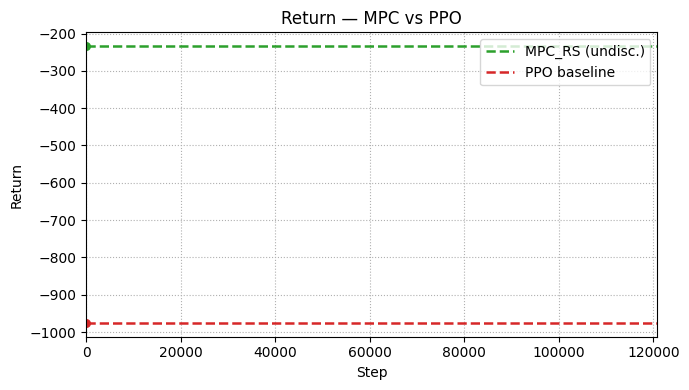

In [11]:
# ---- ROBUST PLOT: MPC vs PPO return ----
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator as ea

# Renk haritası: burayı istediğiniz hex/isim ile değiştirin
COLOR_MAP = {
    'MPC_RS (undisc.)': '#2ca02c',       # green
    'MPC_RS (disc=0.99)': '#9467bd',     # purple
    'PPO baseline': '#d62728',           # red
}

def tb_series(run_dir: str, tag: str):
    files = []
    for root, _, fs in os.walk(run_dir):
        for f in fs:
            if f.startswith("events.out.tfevents"):
                files.append(os.path.join(root, f))
    if not files:
        return None
    dfs=[]
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={"scalars": 10**7})
            acc.Reload()
            if tag in acc.Tags().get("scalars", []):
                s = acc.Scalars(tag)
                if len(s):
                    dfs.append(pd.DataFrame({"step":[i.step for i in s], "val":[i.value for i in s]}))
        except Exception as ex:
            print("[WARN] TB okunamadı:", f, ex)
    if not dfs:
        return None
    df = pd.concat(dfs).groupby("step", as_index=False)["val"].mean().sort_values("step")
    return df

def read_max_steps_from_csv(log_dir: str):
    csv_path = os.path.join(log_dir, "progress.csv")
    if not os.path.exists(csv_path):
        return None
    try:
        df = pd.read_csv(csv_path)
        for c in ["time/total_timesteps","timesteps","total_timesteps"]:
            if c in df.columns:
                return int(np.nanmax(df[c].values))
    except Exception as e:
        print("[WARN] progress.csv okunamadı:", csv_path, e)
    return None

def plot_series_or_horizontal(log_dir: str, label: str, fallback_value=None, x_max=None, tag="eval/return_mean", color=None):
    df = tb_series(log_dir, tag)
    if df is not None and len(df) >= 2:
        plt.plot(df["step"], df["val"], label=label, linewidth=1.8, color=color)
        return int(df["step"].max())
    # Tek nokta veya hiç veri: yatay çizgi (fallback)
    val = None
    if df is not None and len(df) == 1:
        val = float(df["val"].iloc[0])
    elif fallback_value is not None:
        val = float(fallback_value)
    if val is not None:
        if x_max is None or x_max <= 0:
            x_max = 1
        plt.hlines(val, xmin=0, xmax=x_max, linestyles="--", linewidth=1.8, label=label, colors=color)
        plt.scatter([0], [val], s=30, color=color)
        return x_max
    return None

# Mümkünse PPO'nun progress.csv'inden bir x_max alalım
xmax_ppocsv = read_max_steps_from_csv(BASE_LOG)

plt.figure(figsize=(7,4))
# Önce MPC (undiscounted)
xmax_mpc = plot_series_or_horizontal(MPC_LOG, "MPC_RS (undisc.)",
                                     fallback_value=globals().get("mpc_mean", None),
                                     x_max=xmax_ppocsv, tag="eval/return_mean",
                                     color=COLOR_MAP.get('MPC_RS (undisc.)'))

# İstersen iskontolu versiyonu da aynı grafiğe ekleyebilirsin:
xmax_mpc_d = plot_series_or_horizontal(MPC_LOG, "MPC_RS (disc=0.99)",
                                       fallback_value=globals().get("mpc_disc_mean", None),
                                       x_max=xmax_ppocsv, tag="eval/return_mean_discounted",
                                       color=COLOR_MAP.get('MPC_RS (disc=0.99)'))

# PPO baseline
xmax_ppo = plot_series_or_horizontal(BASE_LOG, "PPO baseline",
                                     fallback_value=globals().get("mean_r", None),
                                     x_max=xmax_ppocsv, tag="eval/return_mean",
                                     color=COLOR_MAP.get('PPO baseline'))

# X ekseni sınırını belirgin yap (hangi değer en büyükse onu kullan)
xmax = max([v for v in [xmax_mpc, xmax_mpc_d, xmax_ppo, xmax_ppocsv] if v is not None] or [1])
plt.xlim(0, xmax)

plt.title("Return — MPC vs PPO")
plt.xlabel("Step"); plt.ylabel("Return")
plt.grid(True, linestyle=":", linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# ==== Pygame Render Demosu: MPC ve PPO ====
import numpy as np
import pygame

def _make_rgb_env(env_id=ENV_ID, seed=SEED):
    """
    Render için rgb_array kullanan ayrı bir env açıyoruz.
    Monitor sarmayı kapatıyoruz (render hızını etkilemesin).
    """
    env = gym.make(env_id, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    return env, obs

def _pygame_init(width, height, title="RL Demo"):
    pygame.init()
    surf = pygame.display.set_mode((width, height))
    pygame.display.set_caption(title)
    clock = pygame.time.Clock()
    return surf, clock

def _pygame_frame(surf, frame):
    # frame: (H, W, 3) uint8
    frame = np.ascontiguousarray(frame)  # Surface için contiguous olsun
    h, w = frame.shape[:2]
    pg_surface = pygame.image.frombuffer(frame.tobytes(), (w, h), "RGB")
    surf.blit(pg_surface, (0, 0))
    pygame.display.flip()

def _handle_events():
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            return True
        if event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:
            return True
    return False

def render_demo(policy="MPC", episodes=2, max_steps=500, fps=30, gaussian_std=1.5):
    """
    policy: "MPC" veya "PPO"
    episodes: kaç bölüm render edilecek
    max_steps: bölüm başına maksimum adım
    fps: pencere tazeleme hızı (gözle izlemek için 20-60 arası iyi)
    gaussian_std: MPC için örnekleme std (RandomShootingMPC içinde)
    """
    assert policy in ["MPC", "PPO"], "policy 'MPC' veya 'PPO' olmalı."

    # --- Env ve pencere ---
    env, obs = _make_rgb_env()
    # İlk kareyi alıp pencere boyutunu ayarlayalım
    first_frame = env.render()  # rgb_array
    H, W = first_frame.shape[0], first_frame.shape[1]
    surf, clock = _pygame_init(W, H, title=f"{policy} Demo — {ENV_ID}")

    # --- Politika seçimleri ---
    if policy == "MPC":
        # fm2 ve planner notebookta tanımlı (önceki hücre): fm2, planner
        # İstersen demo için farklı bir std ile geçici planner kullan:
        tmp = gym.make(ENV_ID)
        low, high = float(tmp.action_space.low[0]), float(tmp.action_space.high[0])
        tmp.close()
        # gauss_std çıkartıldı; mevcut RandomShootingMPC API'sine uyuyor
        demo_planner = RandomShootingMPC(fm2, low, high, horizon=25, n_samples=1024,
                                         device=device, sample_type="gaussian")
        def act_fn(state):
            a = demo_planner.act(state)
            return a
    else:  # PPO
        # ppo modeli notebookta eğitildi (ppo değişkeni)
        def act_fn(state):
            a, _ = ppo.predict(state, deterministic=True)
            return a

    # --- Döngü ---
    try:
        for ep in range(episodes):
            obs, info = env.reset(seed=SEED + 100 + ep)
            ret = 0.0
            for t in range(max_steps):
                # olaylar (ESC ile çık)
                if _handle_events():
                    print("[INFO] Render demo sonlandırıldı (ESC/close).")
                    return
                # aksiyon
                a = act_fn(obs)
                obs, r, done, trunc, info = env.step(a)
                ret += r
                # render
                frame = env.render()
                _pygame_frame(surf, frame)
                clock.tick(fps)
                if done or trunc:
                    break
            print(f"[{policy} DEMO] Episode {ep+1}/{episodes} return={ret:.1f}")
    finally:
        pygame.quit()
        env.close()

# ---- Kullanım örnekleri ----
# MPC demo (gaussian örnekleme std=1.5)

#render_demo(policy="MPC", episodes=2, max_steps=400, fps=30)

# PPO demo
#render_demo(policy="PPO", episodes=2, max_steps=400, fps=30)

## Veri Toplama ne kadar kaliteyise model de o kadar kalitelidir.

* Daager veya ön bir Model-free yöntem öğrenip (sadece hareket ettirmesi için) bunu data toplatmak için kullanabiliriz.

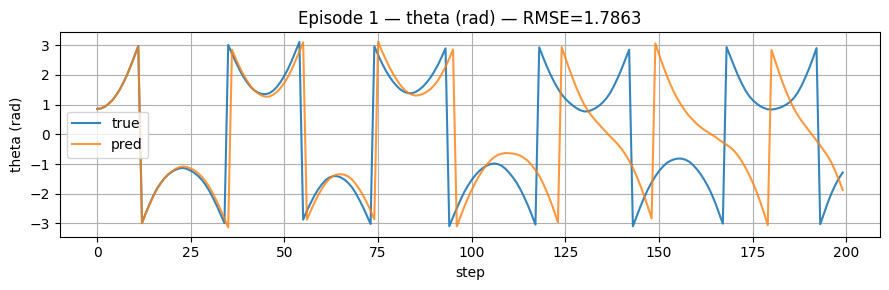

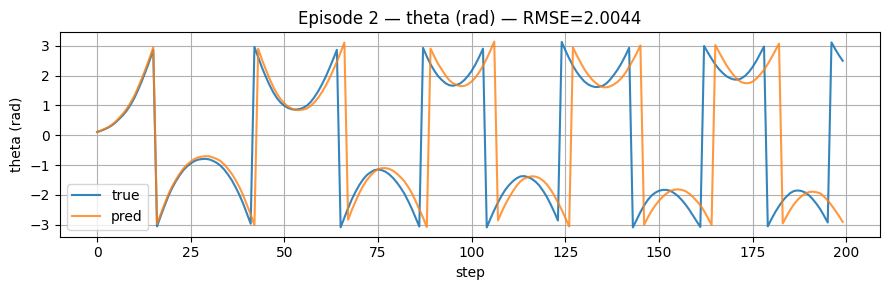

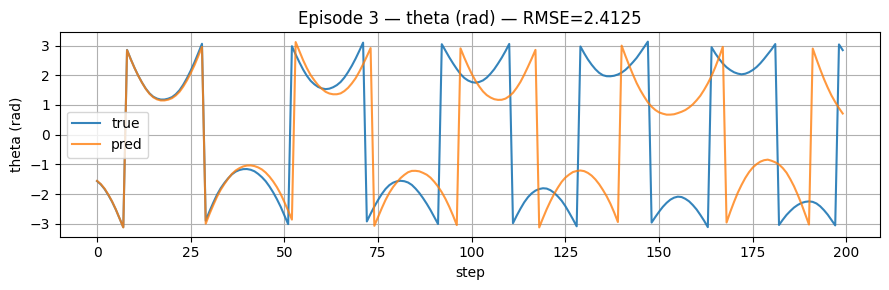

In [15]:
import math, numpy as np, matplotlib.pyplot as plt

def compare_forward_vs_real(model=None, env=None, episodes=3, horizon=200, seed=0):
    """Run random actions on the real env and the forward model (one-step model.step) and plot theta true vs pred."""
    # obtain model
    if model is None:
        if 'fm2' in globals():
            model = fm2
        else:
            model = MLPDynamics(obs_dim, act_dim, hidden=256, predict_delta=True).to(device)
            model.load_state_dict(torch.load(ckpt_path, map_location=device))

    # env to collect true trajectories
    if env is None:
        env = gym.make(ENV_ID)

    for ep in range(episodes):
        obs, info = env.reset(seed=seed + ep)
        # init predicted state from initial observation
        s_pred = torch.as_tensor(np.array(obs, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
        trues = []
        preds = []
        for t in range(horizon):
            a = env.action_space.sample()
            nobs, r, done, trunc, info = env.step(a)
            # true theta
            theta_true = math.atan2(nobs[1], nobs[0])
            trues.append(theta_true)
            # model one-step prediction using the same sampled action
            a_t = torch.as_tensor(np.array(a, dtype=np.float32), dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                s_pred = model.step(s_pred, a_t)
            s_pred_np = s_pred.squeeze(0).cpu().numpy()
            theta_pred = math.atan2(s_pred_np[1], s_pred_np[0])
            preds.append(theta_pred)
            if done or trunc:
                break
        steps = len(trues)
        trues = np.array(trues)
        preds = np.array(preds)
        rmse = float(np.sqrt(((trues - preds)**2).mean())) if steps>0 else float('nan')
        plt.figure(figsize=(9,3))
        plt.plot(np.arange(steps), trues, label='true', alpha=0.9)
        plt.plot(np.arange(steps), preds, label='pred', alpha=0.8)
        plt.title(f'Episode {ep+1} — theta (rad) — RMSE={rmse:.4f}')
        plt.xlabel('step'); plt.ylabel('theta (rad)')
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    env.close()

# Çağır (gerekirse parametreleri değiştirin)
compare_forward_vs_real(episodes=3, horizon=200, seed=0)